## (ML Baselines) Experiment 2 - Binary STAR-GALAXY Classification with RF / SVM / MLP



In [1]:
# Step 0 - Imports & global configuration

import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_val_predict, cross_val_score,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RESULTS_DIR = Path('Ex2_MLAlgos_SG')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Modeling knobs (binary GS encoding: GALAXY=0, STAR=1; QSO is dropped at isin filter)
RANDOM_STATE   = 42
CLASSES        = ['GALAXY', 'STAR']
LABEL_TO_ORD   = {'STAR': 0, 'GALAXY': 1}
ORD_TO_LABEL   = {v: k for k, v in LABEL_TO_ORD.items()}
LABEL_ORDER    = [LABEL_TO_ORD[c] for c in CLASSES]
N_FOLDS        = 5

# ---- Plot aesthetics ------------------------------------------
PALETTE = {
    'GALAXY': {'color': '#1f4e79', 'marker': 's'},
    'STAR':   {'color': '#d62728', 'marker': 'o'},
}
FIGSIZE_SINGLE = (7.0, 5.0)
FIGSIZE_DOUBLE = (13.5, 5.0)

sns.set_style('white')
plt.rcParams.update({
    'figure.dpi':           150, 'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'figure.facecolor':     'white', 'savefig.facecolor':    'white',
    'font.family':          'DejaVu Sans', 'font.size':            11,
    'axes.titlesize':       14, 'axes.titleweight':     'bold',
    'axes.labelsize':       13, 'axes.labelweight':     'normal',
    'axes.spines.top':      True, 'axes.spines.right':    True,
    'axes.spines.bottom':   True, 'axes.spines.left':     True,
    'axes.edgecolor':       'black', 'axes.linewidth':       1.2,
    'xtick.direction':      'in', 'ytick.direction':      'in',
    'xtick.top':            True, 'ytick.right':          True,
    'xtick.major.size':     5.5, 'ytick.major.size':     5.5,
    'xtick.minor.size':     3.0, 'ytick.minor.size':     3.0,
    'xtick.major.width':    1.0, 'ytick.major.width':    1.0,
    'xtick.minor.width':    0.8, 'ytick.minor.width':    0.8,
    'xtick.minor.visible':  True, 'ytick.minor.visible':  True,
    'xtick.labelsize':      11, 'ytick.labelsize':      11,
    'xtick.color':          'black', 'ytick.color':          'black',
    'axes.grid':            False,
    'grid.alpha':           0.25, 'grid.linestyle':       ':', 'grid.color':           '0.5',
    'legend.fontsize':      11, 'legend.framealpha':    0.95,
    'legend.edgecolor':     'black', 'legend.fancybox':      False,
    'lines.linewidth':      2.4, 'lines.markersize':     8,
})

# ---- Shared helpers ------------------------------------------
def _pct_annot(M_norm):
    return np.array([[f'{100*v:.2f}%' for v in row] for row in M_norm])

def _pct_count_annot(M_norm, M_count):
    return np.array([
        [f'{100*M_norm[i, j]:.2f}%' + chr(10) + f'({int(M_count[i, j]):,})'
         for j in range(M_norm.shape[1])]
        for i in range(M_norm.shape[0])
    ])

def _style_cm_axes(ax, title):
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
    ax.set_xlabel('Predicted', labelpad=10)
    ax.set_ylabel('Actual',    labelpad=10)
    ax.set_title(title, fontweight='bold', pad=12)
    plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
    ax.tick_params(axis='y', pad=10)
    ax.tick_params(axis='x', pad=6)

print('Setup complete. Output directory:', RESULTS_DIR.resolve())


Setup complete. Output directory: /home/srinadb/SGExperiments/Photo_Classification/SRFinal/Ex2_MLAlgos_SG


## Step 1 - Load and clean the catalog



In [2]:
CSV_PATH = 'photofeatures_exp2.csv'
df = pd.read_csv(CSV_PATH)
df['class'] = df['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df = df.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df = df[df['class'].isin(CLASSES)].reset_index(drop=True)  # drops QSO -> binary
df['y_ord'] = df['class'].map(LABEL_TO_ORD).astype(int)

print('Loaded', f'{len(df):,}', 'rows from', CSV_PATH, '(binary, QSO dropped)')
print(df['class'].value_counts().reindex(CLASSES))
df.head()

Loaded 99,996 rows from photofeatures_exp2.csv (binary, QSO dropped)
class
GALAXY    50000
STAR      49996
Name: count, dtype: int64


,objid,specobjid,class,run,rerun,camcol,field,ra,dec,redshift,...,extinction_i,dered_z,deVRad_z,psffwhm_z,extinction_z,u_g,g_r,r_i,i_z,y_ord
0,1237645942906028249,1.721649e+18,STAR,109,301,4,158,58.304815,0.086388,0.000081,...,0.476612,17.83383,0.017232,1.035032,0.354512,2.083651,1.672703,1.376972,0.841147,0
1,1237645943433724239,7.633840e+18,GALAXY,109,301,5,18,37.403926,0.629883,0.583263,...,0.052014,19.87971,0.681776,1.253100,0.038689,0.340578,0.425121,0.517006,0.146811,1
2,1237645943435034831,1.700259e+18,STAR,109,301,5,38,40.342530,0.598422,0.000189,...,0.062559,18.89020,0.102533,1.251485,0.046532,2.290590,1.159369,0.443674,0.221241,0
3,1237645943435034871,7.634999e+18,GALAXY,109,301,5,38,40.312519,0.479615,0.399347,...,0.060216,20.66077,0.121812,1.174328,0.044790,0.081373,0.133694,0.372484,-0.091124,1
4,1237645943976493341,1.763250e+18,GALAXY,109,301,6,108,50.779704,0.885646,0.588740,...,0.206408,19.08332,0.392487,1.281757,0.153530,1.356503,2.111229,0.893845,0.347103,1


## Step 2 - Class distribution

Quick sanity check on label balance before splitting. Only GALAXY and STAR remain after the `isin(CLASSES)` filter.

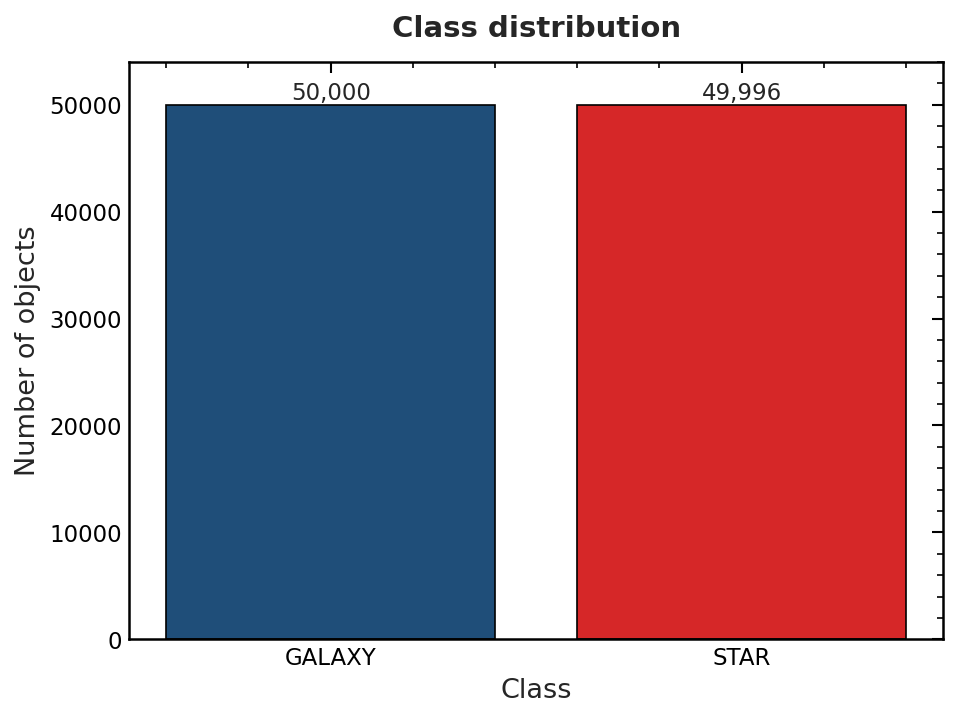

In [3]:
counts = df['class'].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c]['color'] for c in CLASSES],
              edgecolor='black', linewidth=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('Number of objects')
ax.set_title('Class distribution', fontweight='bold', pad=12)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, max(counts.values) * 1.08)
fig.savefig(RESULTS_DIR / 'class_distribution.png')
plt.show()

## Step 3 - Redshift distribution by class

The two populations occupy distinct redshift regimes: stars cluster near $z \approx 0$, galaxies dominate the low-to-mid range. 


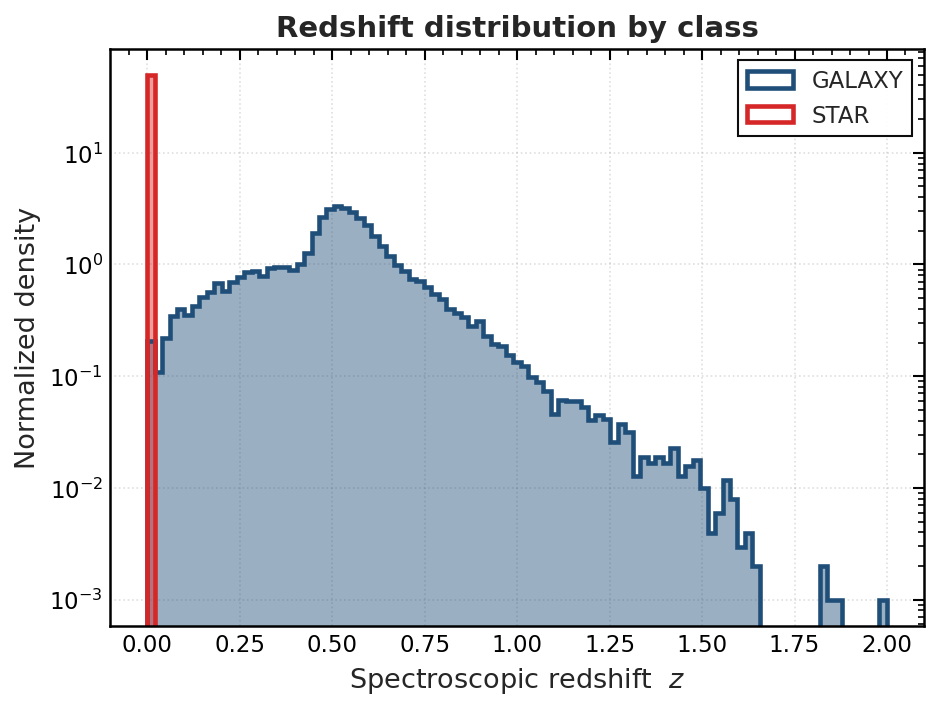

In [4]:
zmax = float(np.quantile(df['redshift'], 1.0))
bins = np.linspace(0, zmax, 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distribution by class')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend()
fig.savefig(RESULTS_DIR / 'redshift_distribution.png')
plt.show()


## Step 4 - Outer stratified split (POOL + TEST)

Single stratified outer split, identical seed and proportion to the SR companion. The 87.5% remainder is the **POOL** on which everything else operates - `GridSearchCV` and the CV-based reporting in Step 7. There is **no** inner TRAIN/VAL sub-split here. TEST stays at 12.5% with `random_state=42`, so the held-out rows are bit-for-bit the same as the SR notebook's TEST.

In [5]:
X = df[['redshift']].values.astype(float)
y = df['y_ord'].values.astype(int)

# --- Outer split: pool (87.5%) + TEST (12.5%) ---
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=0.125, random_state=RANDOM_STATE, stratify=y,
)

def _per_class_counts(y_arr):
    s = pd.Series(y_arr).map(ORD_TO_LABEL)
    return s.value_counts().reindex(CLASSES).astype(int)

total = len(y)
print(f'Total rows           : {total:,}')
print(f'POOL  (~87.5%)       : {len(y_pool):,}   ({100*len(y_pool)/total:.2f}%)')
print(f'TEST  (~12.5%)       : {len(y_test):,}   ({100*len(y_test)/total:.2f}%)')
print()
print('Per-class counts in POOL:'); print(_per_class_counts(y_pool))
print()
print('Per-class counts in TEST:'); print(_per_class_counts(y_test))

Total rows           : 99,996
POOL  (~87.5%)       : 87,496   (87.50%)
TEST  (~12.5%)       : 12,500   (12.50%)

Per-class counts in POOL:
GALAXY    43750
STAR      43746
Name: count, dtype: int64

Per-class counts in TEST:
GALAXY    6250
STAR      6250
Name: count, dtype: int64


## Step 5 - Define models and parameter grids

Three estimators with very small grids that **include paper-like defaults** as one combination each:

- **RF**: `{n_estimators: [100, 200], max_depth: [5, 10, None], min_samples_leaf: [1, 3]}` -> 12 combos. 
- **SVM**: `{C: [0.1, 1.0, 10.0], gamma: ['scale', '0.1']}` -> 6 combos. 
- **MLP**: `{hidden_layer_sizes: [(16,), (32,), (64, 32)], alpha: [1e-3, 1e-4], learning_rate_init: [1e-3]}` -> 6 combos. 



In [6]:
MODELS = {
    'Random Forest': (
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            'n_estimators':     [100, 200],
            'max_depth':        [5, 10, None],
            'min_samples_leaf': [1, 3],
        },
    ),
    'SVM': (
        SVC(
            kernel='rbf',
            cache_size=500,
            probability=True,
            random_state=RANDOM_STATE,
        ),
        {
            'C':     [0.1, 1.0, 10.0],
            'gamma': ['scale', '0.1'],
        },
    ),
    'MLP': (
        MLPClassifier(
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        {
            'hidden_layer_sizes':  [(16,), (32,), (32, 16)],
            'alpha':               [1e-3, 1e-4],
            'learning_rate_init':  [1e-3],
        },
    ),
}

for name, (est, grid) in MODELS.items():
    n_combos = int(np.prod([len(v) for v in grid.values()]))
    print(f'{name:>13s}: {n_combos} combos x {N_FOLDS} folds')

Random Forest: 12 combos x 5 folds
          SVM: 6 combos x 5 folds
          MLP: 6 combos x 5 folds


## Step 6 - GridSearchCV on the POOL

Stratified 5-fold inside `GridSearchCV`, `scoring='f1_macro'`, `refit=True`, `n_jobs=-1`. The grid search runs on the **full POOL** (`X_pool, y_pool`) for all three models. With `refit=True`, `gs.best_estimator_` returns the best-configuration estimator already refit on the entire pool, ready for direct deployment on TEST and EXTERNAL in Steps 8-9. Best hyper-parameters are persisted to JSON.

In [7]:
cv5 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

BEST_ESTIMATORS = {}
BEST_PARAMS     = {}

for name, (estimator, grid) in MODELS.items():
    print(f'\n=== {name}: GridSearchCV on POOL ({len(y_pool):,} rows) ===')

    gs = GridSearchCV(
        estimator, grid,
        cv=cv5, scoring='f1_macro',
        n_jobs=-1, refit=True,
    )
    gs.fit(X_pool, y_pool)

    BEST_ESTIMATORS[name] = gs.best_estimator_  # already refit on full POOL
    BEST_PARAMS[name]     = gs.best_params_

    print('   best CV f1_macro (POOL, 5-fold):', f'{gs.best_score_:.4f}')
    print('   best params:', gs.best_params_)

    serializable = {k: (list(v) if isinstance(v, tuple) else v) for k, v in gs.best_params_.items()}
    with open(RESULTS_DIR / f'{name}_best_params.json', 'w') as f:
        json.dump(serializable, f, indent=2)

print('\nAll models grid-searched on the same POOL; best_estimator_ already refit on POOL.')


=== Random Forest: GridSearchCV on POOL (87,496 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9985
   best params: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100}

=== SVM: GridSearchCV on POOL (87,496 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9981
   best params: {'C': 10.0, 'gamma': 'scale'}

=== MLP: GridSearchCV on POOL (87,496 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9979
   best params: {'alpha': 0.0001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}

All models grid-searched on the same POOL; best_estimator_ already refit on POOL.


## Step 6b - Persist the trained models to disk

The three estimators in `BEST_ESTIMATORS` are `gs.best_estimator_` objects, which `GridSearchCV(refit=True)` has already refit on the **full POOL**. They are the final trained models: Step 8's per-fold loop works on `clone(best_est)` copies, so nothing downstream re-fits or mutates them.

Each is serialized to its own `.pkl` via `joblib` (the recommended serializer for scikit-learn estimators - same pickle protocol, but far more efficient for the large NumPy arrays inside the RF and MLP). Files land in `Ex2_MLAlgos_SG/saved_models/`.

Because the pipeline has **no preprocessing stage** - `X = df[['redshift']]` is fed to the estimators directly - a reloaded estimator is self-sufficient for inference:

```python
import joblib, numpy as np
model = joblib.load('Ex2_MLAlgos_SG/saved_models/random_forest_star_galaxy.pkl')
model.predict(np.array([[0.0004], [0.35]]))   # -> array([0, 1]) == [STAR, GALAXY]
```

Mind the label convention when interpreting output: `LABEL_TO_ORD = {'STAR': 0, 'GALAXY': 1}`, i.e. **0 = STAR, 1 = GALAXY** (this is deliberately *not* the alphabetical order of `CLASSES`). All three were fit with `probability=True` / native support, so `predict_proba` is available on reload as well.


In [8]:
# Step 6b - Save each trained model as its own .pkl (no retraining needed later)

import joblib

MODELS_DIR = RESULTS_DIR / 'saved_models'
MODELS_DIR.mkdir(exist_ok=True, parents=True)

# Descriptive, filesystem-safe filename per estimator
MODEL_FILENAMES = {
    'Random Forest': 'random_forest_star_galaxy.pkl',
    'SVM':           'svm_rbf_star_galaxy.pkl',
    'MLP':           'mlp_star_galaxy.pkl',
}

SAVED_MODEL_PATHS = {}

for name, model in BEST_ESTIMATORS.items():
    out_path = MODELS_DIR / MODEL_FILENAMES[name]
    joblib.dump(model, out_path, compress=3)
    SAVED_MODEL_PATHS[name] = out_path
    size_kb = out_path.stat().st_size / 1024
    print(f'{name:>13s} -> {out_path}  ({size_kb:,.1f} KiB)')

# --- Reload check: loaded models must reproduce the in-memory predictions ---
print('\nVerifying reloaded models...')
for name, model in BEST_ESTIMATORS.items():
    reloaded = joblib.load(SAVED_MODEL_PATHS[name])
    same_pred  = np.array_equal(reloaded.predict(X_test), model.predict(X_test))
    same_proba = np.allclose(reloaded.predict_proba(X_test), model.predict_proba(X_test))
    assert same_pred and same_proba, f'Reloaded {name} does not match the in-memory model'
    print(f'{name:>13s}: reload OK - predict and predict_proba match on TEST')

print(f'\nAll {len(SAVED_MODEL_PATHS)} trained models saved to {MODELS_DIR.resolve()}')


Random Forest -> Ex2_MLAlgos_SG/saved_models/random_forest_star_galaxy.pkl  (241.1 KiB)
          SVM -> Ex2_MLAlgos_SG/saved_models/svm_rbf_star_galaxy.pkl  (5.6 KiB)
          MLP -> Ex2_MLAlgos_SG/saved_models/mlp_star_galaxy.pkl  (5.7 KiB)

Verifying reloaded models...
Random Forest: reload OK - predict and predict_proba match on TEST
          SVM: reload OK - predict and predict_proba match on TEST
          MLP: reload OK - predict and predict_proba match on TEST

All 3 trained models saved to /home/srinadb/SGExperiments/Photo_Classification/SRFinal/Ex2_MLAlgos_SG/saved_models


## Step 7 - 5-fold CV on POOL (mean +/- std + CV confusion matrix)

For each best estimator, we run `cross_val_predict` and `cross_val_score` on the **POOL** with `StratifiedKFold(N_FOLDS=5, shuffle=True, random_state=42)`. The CV confusion matrix is row-normalized and annotated via `_pct_annot` (annot size 14); mean +/- std are reported for accuracy / precision_macro / recall_macro / f1_macro and saved to `<model>_cv_summary.csv`.


=== Random Forest: 5-fold CV on POOL (87,496 rows) ===


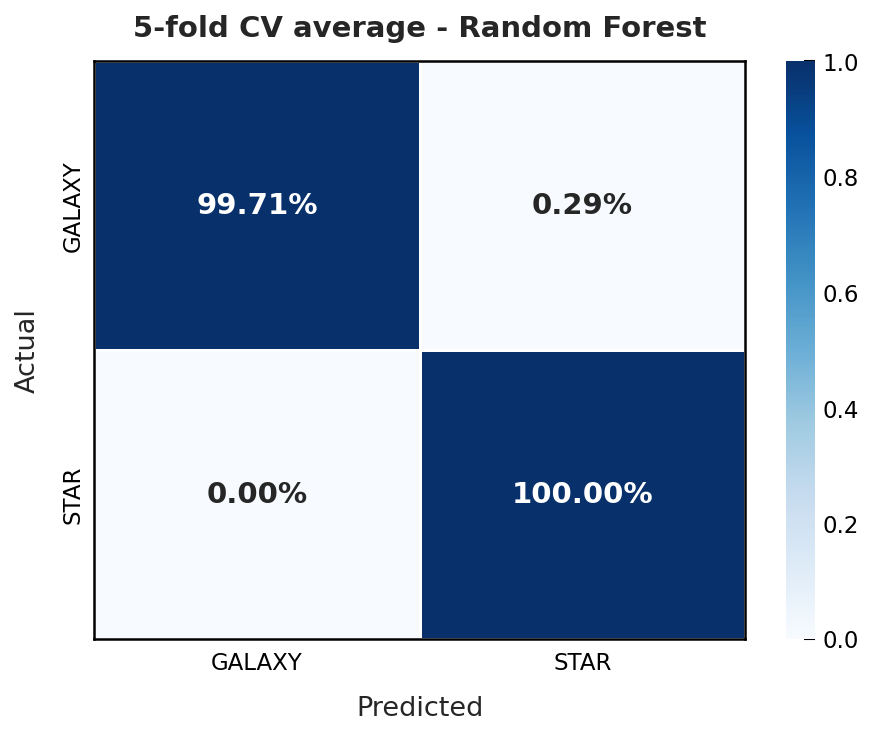

         metric   mean    std
       accuracy 0.9985 0.0002
precision_macro 0.9985 0.0002
   recall_macro 0.9985 0.0002
       f1_macro 0.9985 0.0002

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9971    1.0000    0.9985     43746
        STAR     1.0000    0.9971    0.9985     43750

    accuracy                         0.9985     87496
   macro avg     0.9985    0.9985    0.9985     87496
weighted avg     0.9985    0.9985    0.9985     87496


=== SVM: 5-fold CV on POOL (87,496 rows) ===


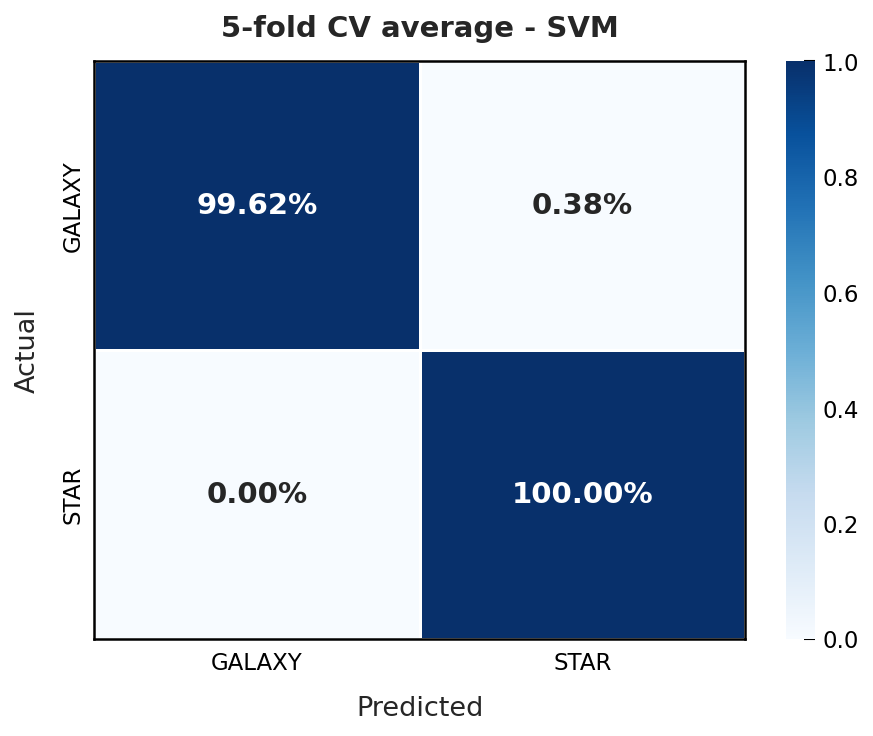

         metric   mean    std
       accuracy 0.9981 0.0002
precision_macro 0.9981 0.0002
   recall_macro 0.9981 0.0002
       f1_macro 0.9981 0.0002

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9962    1.0000    0.9981     43746
        STAR     1.0000    0.9962    0.9981     43750

    accuracy                         0.9981     87496
   macro avg     0.9981    0.9981    0.9981     87496
weighted avg     0.9981    0.9981    0.9981     87496


=== MLP: 5-fold CV on POOL (87,496 rows) ===


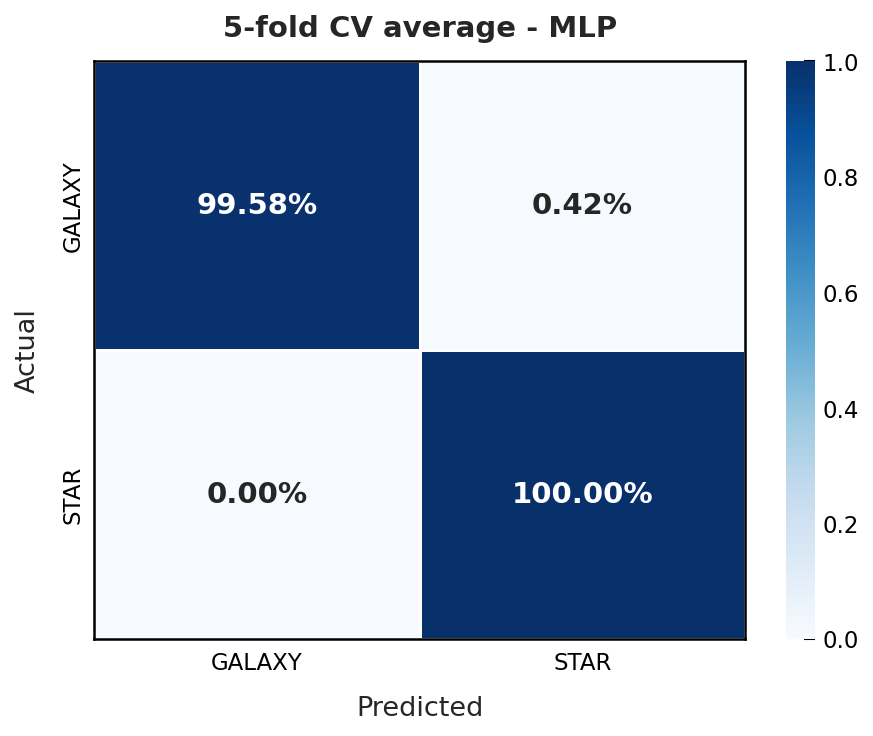

         metric   mean    std
       accuracy 0.9979 0.0004
precision_macro 0.9979 0.0004
   recall_macro 0.9979 0.0004
       f1_macro 0.9979 0.0004

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9958    1.0000    0.9979     43746
        STAR     1.0000    0.9958    0.9979     43750

    accuracy                         0.9979     87496
   macro avg     0.9979    0.9979    0.9979     87496
weighted avg     0.9979    0.9979    0.9979     87496



In [9]:
cv_scoring = {
    'accuracy':        'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro':    'recall_macro',
    'f1_macro':        'f1_macro',
}

cv_summary_rows = []

for name, model in BEST_ESTIMATORS.items():
    print(f'\n=== {name}: 5-fold CV on POOL ({len(y_pool):,} rows) ===')

    y_cv_pred = cross_val_predict(
        model, X_pool, y_pool,
        cv=cv5, n_jobs=-1,
    )

    cm_cv_count = confusion_matrix(y_pool, y_cv_pred, labels=LABEL_ORDER)
    cm_cv_norm  = cm_cv_count / cm_cv_count.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    sns.heatmap(cm_cv_norm, annot=_pct_annot(cm_cv_norm), fmt='', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=True, vmin=0, vmax=1,
                annot_kws={'size': 14, 'weight': 'bold'},
                linewidths=0.6, linecolor='white')
    _style_cm_axes(ax, f'5-fold CV average - {name}')
    fig.savefig(RESULTS_DIR / f'confusion_matrix_cv_{name}.png')
    plt.show()

    per_metric = {}
    for metric_name, metric_key in cv_scoring.items():
        scores = cross_val_score(
            model, X_pool, y_pool,
            cv=cv5, scoring=metric_key, n_jobs=-1,
        )
        per_metric[metric_name] = {
            'mean':   float(np.mean(scores)),
            'std':    float(np.std(scores, ddof=0)),
            'scores': [float(s) for s in scores],
        }

    summary_df = pd.DataFrame({
        'metric': list(per_metric.keys()),
        'mean':   [per_metric[m]['mean'] for m in per_metric],
        'std':    [per_metric[m]['std']  for m in per_metric],
    })
    summary_df.to_csv(RESULTS_DIR / f'{name}_cv_summary.csv', index=False)

    per_metric_df = pd.DataFrame(
        {m: per_metric[m]['scores'] for m in per_metric},
        index=[f'fold_{i+1}' for i in range(N_FOLDS)],
    )
    per_metric_df.to_csv(RESULTS_DIR / f'{name}_cv_per_metric.csv')

    print(summary_df.to_string(index=False, formatters={
        'mean': '{:.4f}'.format, 'std': '{:.4f}'.format,
    }))
    print('\nClassification report (cross_val_predict on POOL):')
    print(classification_report(
        y_pool, y_cv_pred,
        labels=[0, 1], target_names=CLASSES, digits=4, zero_division=0,
    ))

    cv_summary_rows.append({
        'model':           name,
        'cv_accuracy':     per_metric['accuracy']['mean'],
        'cv_accuracy_std': per_metric['accuracy']['std'],
        'cv_f1_macro':     per_metric['f1_macro']['mean'],
        'cv_f1_macro_std': per_metric['f1_macro']['std'],
    })

## Step 8 - TEST evaluation 




=== Random Forest: TEST (headline + per-fold std) ===
accuracy        : 0.9982
precision_macro : 0.9982
recall_macro    : 0.9982
f1_macro        : 0.9982

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9963    1.0000    0.9982      6250
        STAR     1.0000    0.9963    0.9982      6250

    accuracy                         0.9982     12500
   macro avg     0.9982    0.9982    0.9982     12500
weighted avg     0.9982    0.9982    0.9982     12500



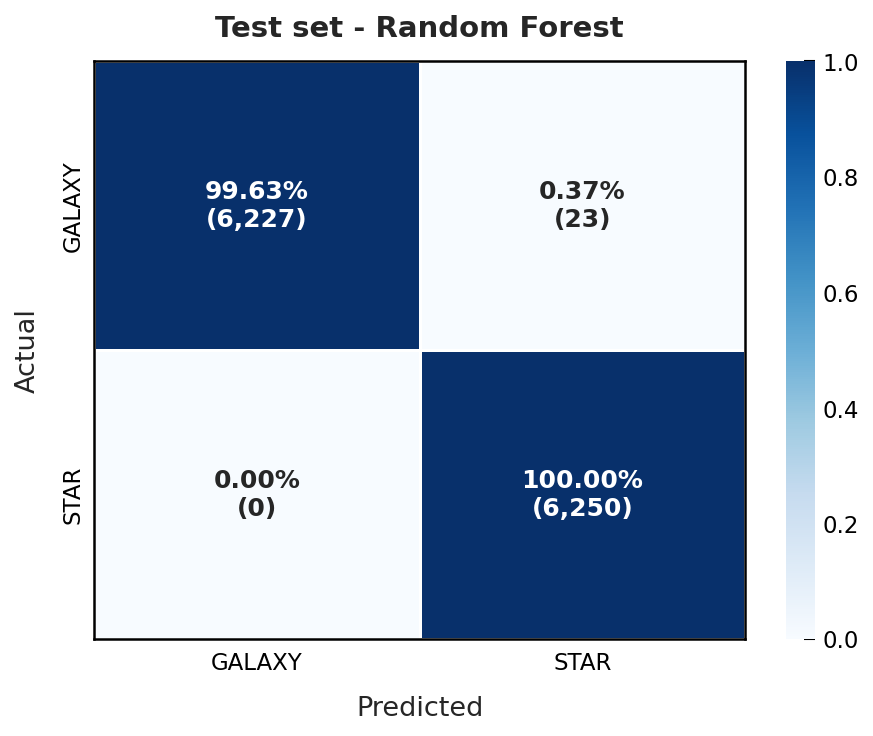


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9982 0.0000
precision_macro 0.9982 0.0000
   recall_macro 0.9982 0.0000
       f1_macro 0.9982 0.0000

=== SVM: TEST (headline + per-fold std) ===
accuracy        : 0.9980
precision_macro : 0.9980
recall_macro    : 0.9980
f1_macro        : 0.9980

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9960    1.0000    0.9980      6250
        STAR     1.0000    0.9960    0.9980      6250

    accuracy                         0.9980     12500
   macro avg     0.9980    0.9980    0.9980     12500
weighted avg     0.9980    0.9980    0.9980     12500



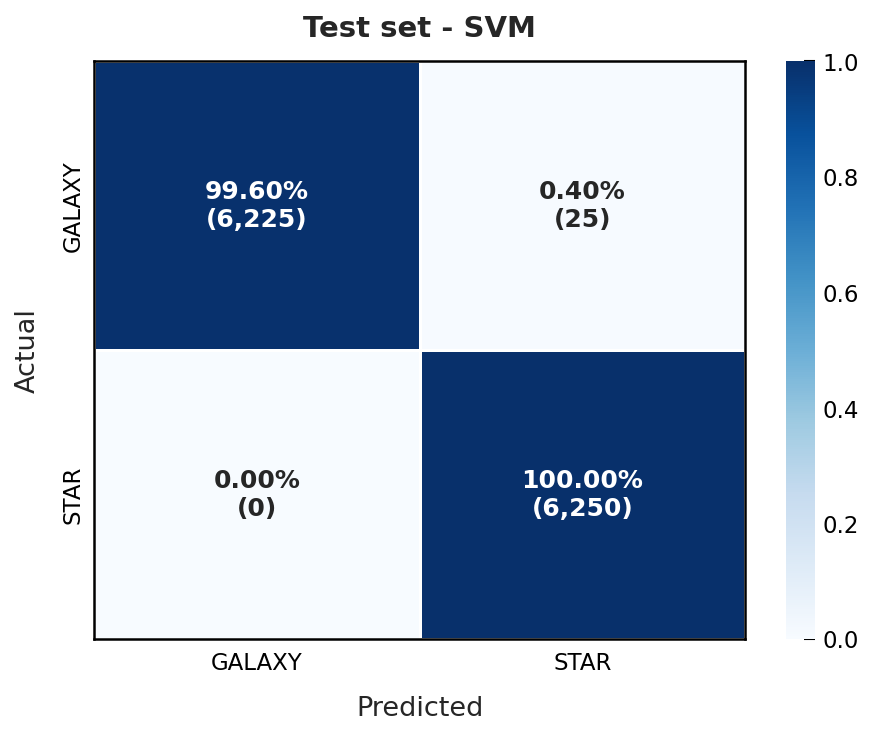


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9980 0.0000
precision_macro 0.9980 0.0000
   recall_macro 0.9980 0.0000
       f1_macro 0.9980 0.0000

=== MLP: TEST (headline + per-fold std) ===
accuracy        : 0.9980
precision_macro : 0.9980
recall_macro    : 0.9980
f1_macro        : 0.9980

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9960    1.0000    0.9980      6250
        STAR     1.0000    0.9960    0.9980      6250

    accuracy                         0.9980     12500
   macro avg     0.9980    0.9980    0.9980     12500
weighted avg     0.9980    0.9980    0.9980     12500



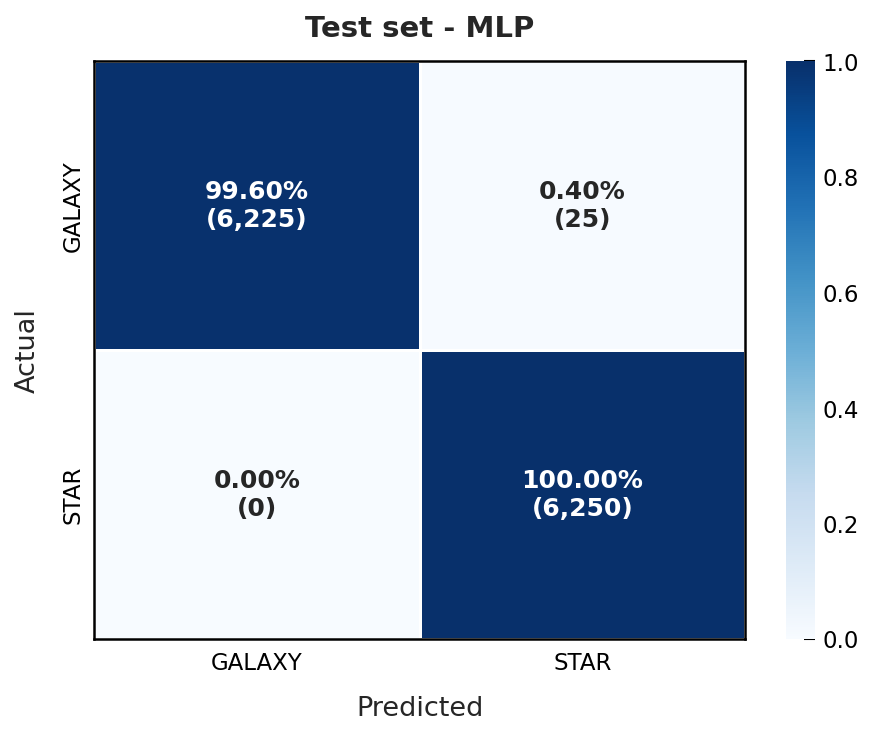


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9978 0.0002
precision_macro 0.9978 0.0002
   recall_macro 0.9978 0.0002
       f1_macro 0.9978 0.0002


In [10]:
test_summary_rows = []

for name, best_est in BEST_ESTIMATORS.items():
    print(f'\n=== {name}: TEST (headline + per-fold std) ===')

    # --- Headline: predict TEST with gs.best_estimator_ (refit on POOL) ---
    y_pred = best_est.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    f1m  = f1_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)

    print(f'accuracy        : {acc:.4f}')
    print(f'precision_macro : {prec:.4f}')
    print(f'recall_macro    : {rec:.4f}')
    print(f'f1_macro        : {f1m:.4f}')
    print('\nclassification_report:')
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1], target_names=CLASSES, digits=4, zero_division=0,
    ))

    metrics_df = pd.DataFrame({
        'metric': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        'value':  [acc, prec, rec, f1m],
    })
    metrics_df.to_csv(RESULTS_DIR / f'{name}_test_metrics.csv', index=False)

    cm_count = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    cm_norm  = cm_count / cm_count.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    sns.heatmap(cm_norm, annot=_pct_count_annot(cm_norm, cm_count), fmt='', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=True, vmin=0, vmax=1,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.6, linecolor='white')
    _style_cm_axes(ax, f'Test set - {name}')
    fig.savefig(RESULTS_DIR / f'confusion_matrix_test_{name}.png')
    plt.show()

    # --- Per-fold std on TEST: refit on each fold's tr_idx, predict TEST ---
    fold_rows = []
    for fi, (tr_idx, _) in enumerate(cv5.split(X_pool, y_pool), start=1):
        fold_est = clone(best_est)
        fold_est.fit(X_pool[tr_idx], y_pool[tr_idx])
        yp_f = fold_est.predict(X_test)
        fold_rows.append({
            'fold':            fi,
            'accuracy':        accuracy_score(y_test, yp_f),
            'precision_macro': precision_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'recall_macro':    recall_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'f1_macro':        f1_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
        })
    fold_df = pd.DataFrame(fold_rows)
    fold_df.to_csv(RESULTS_DIR / f'{name}_test_per_fold.csv', index=False)

    metric_cols = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    std_summary_df = pd.DataFrame({
        'metric': metric_cols,
        'mean':   [fold_df[m].mean() for m in metric_cols],
        'std':    [fold_df[m].std(ddof=1) for m in metric_cols],
    })
    std_summary_df.to_csv(RESULTS_DIR / f'{name}_test_metrics_with_std.csv', index=False)
    print('\nTEST mean +/- std across 5 fold-refits:')
    print(std_summary_df.to_string(index=False, formatters={
        'mean': '{:.4f}'.format, 'std': '{:.4f}'.format,
    }))

    test_summary_rows.append({
        'model':                name,
        'test_accuracy':        acc,
        'test_precision_macro': prec,
        'test_recall_macro':    rec,
        'test_f1_macro':        f1m,
        'test_accuracy_std':    fold_df['accuracy'].std(ddof=1),
        'test_f1_macro_std':    fold_df['f1_macro'].std(ddof=1),
    })

## Step 9 - Summary table

Consolidated CV / TEST accuracy and macro-F1 for RF, SVM, MLP, with std columns where applicable. Use this as the side-by-side comparison against the SR companion's `summary_metrics.csv`.

In [11]:
cv_df   = pd.DataFrame(cv_summary_rows).set_index('model')
test_df = pd.DataFrame(test_summary_rows).set_index('model')

summary_df = pd.concat([cv_df, test_df], axis=1).reset_index()
summary_df = summary_df[[
    'model',
    'cv_accuracy', 'cv_accuracy_std', 'cv_f1_macro', 'cv_f1_macro_std',
    'test_accuracy', 'test_accuracy_std', 'test_f1_macro', 'test_f1_macro_std'
]]

summary_df.to_csv(RESULTS_DIR / 'summary_all_models.csv', index=False)

fmts = {c: '{:.4f}'.format for c in summary_df.columns if c != 'model'}
print(summary_df.to_string(index=False, formatters=fmts))

        model cv_accuracy cv_accuracy_std cv_f1_macro cv_f1_macro_std test_accuracy test_accuracy_std test_f1_macro test_f1_macro_std
Random Forest      0.9985          0.0002      0.9985          0.0002        0.9982            0.0000        0.9982            0.0000
          SVM      0.9981          0.0002      0.9981          0.0002        0.9980            0.0000        0.9980            0.0000
          MLP      0.9979          0.0004      0.9979          0.0004        0.9980            0.0002        0.9980            0.0002
